This analysis notebook extracts simulation results and uses the EPR method to calculate the system Hamiltonian parameters.

This notebook must be run after running ```example01_script.py```, which generates the AWS Palace configuration file and simulates it on an HPC. 

In [1]:
from pypalace import Config,Simulation
from pypalace.analysis import EPR
import numpy as np

In [2]:
''' paths '''
mesh_dir = "mesh/"
config_dir = "config/"

create a ```Config``` and corresponding ```Simulation``` objects from pre-simulated configuration file

In [3]:
''' create Config object '''
meshfile = mesh_dir + "qubit_resonator_mesh.bdf"
my_config = Config.load_config(config_dir + "example01.json")

''' create Simulation object '''
cavity_qubit_sim = Simulation(my_config,None)

## Field visualization

Visualize the electric field magnitude to figure out the qubit & resonator modes for EPR analysis.

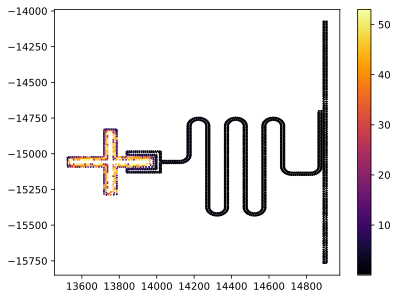

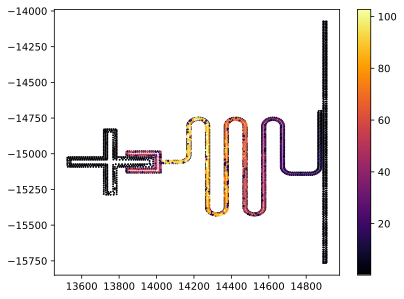

In [4]:
# qubit
cavity_qubit_sim.plot_field(field="E",index=1,save="Figures/qubit_mode.png")

# resonator
cavity_qubit_sim.plot_field(field="E",index=2,save="Figures/resonator_mode.png") 

Results from the plots above confirm that mode 1 corresponds to the qubit and mode 2 corresponds to the resonator. We can use this information to help us with EPR quantization.

## EPR analysis 

Below we extract useful information directly from the electromagnetic Palace simulation

In [5]:
''' get '''
qubit_mode = 1
resonator_mode = 2
JJ_port_index = 1 # user-defined port (see example01_scripy.py)

# as we defined it example01_script.py --> will add tools to extract this automatically in the future
LJ = 14e-09

# qubit parameters
f_q = cavity_qubit_sim.get_frequency_eigenmode(qubit_mode) # qubit frequency in Hz
p_q = cavity_qubit_sim.get_portEPR(JJ_port_index,qubit_mode) # qubit EPR to JJ

# resonator parameters
f_r = cavity_qubit_sim.get_frequency_eigenmode(resonator_mode) # resonator frequency in Hz
p_r = cavity_qubit_sim.get_portEPR(JJ_port_index,resonator_mode) # resonator EPR to JJ
kappa = cavity_qubit_sim.get_kappa_eigenmode(resonator_mode)

Extract Hamiltonian parameters with EPR 

In [6]:
# calculate H params
alpha = EPR.calculate_anharmonicity(p_q,f_q,LJ) # unitless, GHz, Henries, returns in Hz
chi = EPR.calculate_dispersive_shift(p_q,p_r,f_q,f_r,LJ) # unitless, unitless, GHz, GHz, Henries, returns in Hz
g = EPR.calculate_coupling_strength(f_q,f_r,alpha,chi) # Hz

# scale to commonly used units
f_q = f_q / 1e9 # GHz
f_r = f_r / 1e9 # GHz
alpha = alpha / 1e6 # MHz
kappa = kappa / 1e3 # kHz
chi = chi / 1e3 # kHz
g = g / 1e6 # MHz

print("----------------------------")
print("Qubit Hamiltonian parameters")
print("----------------------------")
print(f"Frequency [GHz] = {f_q:.2f}")
print(f"Anharmonicity (⍺) [MHz] = {alpha:.2f} \n")
print("----------------------------")
print("Cavity Hamiltonian parameters")
print("----------------------------")
print(f"Frequency [GHz] = {f_r:.2f}")
print(f"kappa (κ) [kHz] = {kappa:.2f} \n") # for kappa_loaded, we need driven simulations, see example03 of pyPalace
print("----------------------------")
print("Cavity-Qubit Hamiltonian parameters")
print("----------------------------")
print(f"Chi Shift [kHz] = {chi:.2f}")
print(f"Coupling strength (g) [MHz] = {g:.2f}\n")

----------------------------
Qubit Hamiltonian parameters
----------------------------
Frequency [GHz] = 4.46
Anharmonicity (⍺) [MHz] = -208.44 

----------------------------
Cavity Hamiltonian parameters
----------------------------
Frequency [GHz] = 6.56
kappa (κ) [kHz] = 337.75 

----------------------------
Cavity-Qubit Hamiltonian parameters
----------------------------
Chi Shift [kHz] = -288.94
Coupling strength (g) [MHz] = 56.96

